# Topic 1.2 - 关系型数据库基本概念

## 1. 数据库核心概念

我们先来预览一下数据库的核心概念：

- 数据 - Data：数据是由一个或多个符号组成的序列，通过特定的解释行为赋予意义

- 元数据 - Metadata：描述数据的数据，提供关于数据的结构、属性和关系的信息，具体包括以下三种：

    - 描述性元数据 (Descriptive Metadata)：用于发现和识别的资源，例如数据的标题、作者、创建日期等
    - 结构性元数据 (Structural Metadata)：数据是如何组织的，以及数据之间的关系，例如数据表中有哪些列，每列的列名和数据格式是什么，以及数据表之间的关系是什么
    - 管理性元数据 (Administrative Metadata)：数据是什么时候以及如何创建的，什么时候以及如何修改的，数据的访问权限是什么，以及数据的使用限制是什么

- 数据库 - Database：数据库是一个有组织的数据集合，通常以电子方式存储在计算机系统中，数据库可以是关系型数据库，也可以是非关系型数据库

- 数据库管理系统 - Database Management System (DBMS)：数据库管理系统是一个软件系统，提供创建、管理和操作数据库的工具和功能，DBMS允许用户定义、创建、查询、更新和管理数据库中的数据，同时还提供数据安全性、完整性和并发控制等功能

- 数据库系统 - Database System：数据库与数据库管理系统的结合体，数据库系统包括数据库和数据库管理系统两部分，数据库系统提供了一个完整的环境，用于存储、管理和操作数据

我们用之前举过的 B 站的例子来说明这些概念：

- 数据 - B 站上的视频、用户信息、弹幕、评论等都是数据

- 元数据 - 就拿视频来说：

    - 描述性元数据：视频的标题、作者、上传日期等
    - 结构性元数据：视频的分辨率、帧率、时长等
    - 管理性元数据：视频的上传时间、修改时间、访问权限等

- 数据库 - B 站将所有的视频等数据，都存放在一个或多个数据库中

- 数据库管理系统 - 事实上，一般大型互联网公司的数据库管理系统都不止一种：

    - 给外部用户使用的就是客户端，也就是大家能在 APP Store 里下载到的数据库软件，通过这个软件，大家可以对自己的视频进行查询、上传、修改、删除等操作，当然一个内在的访问控制逻辑是大家只能管理自己的视频，对于别人的视频我们只能查询
    - 而 B 站的内部员工，比如说视频审核员，他们需要一个专门的数据库管理系统来管理所有的视频数据，这个系统可能是一个内部开发的软件系统，提供了更强大的功能和权限，允许他们对所有的视频进行查询、审核、修改等操作

- 数据库系统 - 就是数据库和数据库管理系统的结合体，B 站的数据库系统包括了存储视频数据的数据库，以及提供管理这些数据的所有软件系统

以下一张图就总结了数据库系统在企业中的作用：

<div align="center">
    <img src="./图1.png" width="400">
</div>


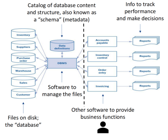

## 2. 关系型数据库的核心概念

### (1) 关系型数据库的定义和特点

关系型数据库，说白了就是多张表格存储在一起，表格与表格之间是有一定关系的，它的主要特点包括：

- 每张表格都有一个或多个唯一字段来标识实体，这样的字段就叫做主键 (Primary Key, PK)：

    - 例如我们有一个客户表，客户 ID 字段可能是主键，因为每个客户都有一个唯一的客户 ID 来标识自己
    - 一般情况下，姓名这个字段就不能作为主键，因为可能会有多个客户叫同样的名字，这样就无法唯一标识一个客户了

- 表格之间通过引用字段来描述实体之间的关系，这样用来连接不同表格的字段就叫做外键 (Foreign Key, FK)：

    - 例如我们有两个表格，一个是用户表，当中有客户 ID、姓名、地址等字段，另一个是订单表，当中有订单 ID、客户 ID、订单日期等字段
    - 这样，在订单表中，客户 ID 就是一个外键，它引用了用户表中的客户 ID 字段，这样我们就可以通过订单表中的客户 ID 来找到对应的用户信息了


- 表格中可能有某些字段是必填的，不能留空，这样的字段就叫做必填字段 (Required Field)：

    - 大家平时在网上填一些表的时候，会遇到一些字段旁边有一个星号，这个星号就表示这个字段是必填的，必须要填写才能提交表单
    - 例如在用户注册表单中，通常用户名、密码、邮箱等字段都是必填的，因为这些信息对于用户的身份验证和后续的服务提供是非常重要的

- 表格中的字段除了是否是必填字段外，还有其他的一些特征，例如数据类型、默认值、约束条件等：

    - 数据类型 (Data Type)：字段的数据类型决定了这个字段可以存储什么样的数据，例如数值、字符串、日期等
    - 默认值 (Default Value)：如果在插入数据时没有提供这个字段的值，那么数据库会使用默认值来填充这个字段
    - 约束条件 (Constraints)：约束条件是对字段值的一些限制，比方说要求年龄必须大于 0

关系型数据库中有以下一些重要概念：

| 概念                               | 定义                       |
|----------------------------------|--------------------------|
| 行 (Row / Record / Case)          | 表格中的一条记录                 |
| 列 (Column / Field / Variable)    | 代表一个属性                   |
| 表格 (Table / Entity)              | 由行和列组成的数据集合，所有行具有相同的列结构  |
| 结构 (Structure)                   | 一个表格中的列，以及列的数据类型、约束条件等规则 |
| 模式 (Schema)                      | 数据库中所有表格的结构的集合，以及数据库中表格之间的关系 |

### (2) 关系型数据库的规范化

规范化 (Normalization) 是关系型数据库设计中的一个重要概念，简单理解就是大表拆小表，来减少冗余和提高数据一致性。

我们来看以下这个例子，来体验以下规范化的过程：

- 我们就拿一个便利店来举例，便利店的数据库内，我们维护两张表，进货表和卖货表

- 首先，进货我们可以记录：进货日期时间、进的什么商品、数量是多少、价格是多少、供货商是谁、哪个员工签收的，同样，卖货我们可以记录，卖货日期时间、卖的什么商品、数量是多少、价格是多少、卖给了哪个顾客、哪个员工卖出的，这样，进货和卖货的表我们就可以写出两个样例出来：

<div align="center">
    <img src="./图2.png" width="700">
</div>

- 这时，便利店老板出了一个问题，那就是顾客中，这两位John其实是两个完全不同的人，他俩同名而已，所以我们提出的解决方案是，建立一个Customer ID，所有顾客的Customer ID是绝对不同的，这样来做到区分顾客：

<div align="center">
    <img src="./图3.png" width="700">
</div>

- 之后，我们又发现了一个问题，那就是销售表中，又记录顾客ID，又记录顾客姓名是没必要的，我们可以新建一个顾客表，之后在销售表中只记录顾客ID，如果想知道姓名，只需查找我们新建的顾客表即可：

<div align="center">
    <img src="./图4.png" width="800">
</div>

- 有了这个思路之后，我们发现，不仅顾客可以这样处理，供货商、员工、商品，其实都可以分别建表，并且在进货和卖货表中只记录ID：

<div align="center">
    <img src="./图5.png" width="800">
</div>

那么以上这个过程就是关系型数据库的规范化过程，表面上来看就是大表拆小表：

- 这样做的一个好处就是减少冗余，如果都拆成小表之后，顾客的姓名、地址、联系方式等信息就只在顾客表中记录一次了，而不是在销售表中每一行都记录一次，这样就减少了数据的冗余
- 这样做的另一个好处就是提高数据的一致性，如果顾客的姓名发生了变化，我们只需要在顾客表中修改一次就好了，而不需要在销售表中每一行都修改一次，这样就提高了数据的一致性

### (3) 主键与外键

键 (Key) 是关系型数据库中的一个重要概念，但是定义其实很简单，键就是用来唯一标识一行数据的字段或者字段组合

- 也就是说，键的值在表格中是唯一的，不能重复的，这样我们就可以通过这个键来唯一标识一行数据了
- 有的时候，单个字段的值就可以做为键，比方说学生表中，学生 ID 这个字段的值就可以唯一标识一行数据：

<div align="center">
    <img src="./图6.png" width="250">
</div>

- 但有的时候，可能需要两个或多个字段的值，组合在一起才能作为键，这时我们就叫做复合键，比方说学科表中，学科和学期这两个字段的值组合在一起才能唯一标识一行数据：

<div align="center">
    <img src="./图7.png" width="300">
</div>

从上面的定义我们可以看出来：

- 一个表中，只要是满足可以唯一标识一行数据的字段或者字段组合，都可以叫做键：
- 因此，一个表中可能有多个字段或字段组合，都满足键的定义，比方说学生信息表中，学生 ID、身份证号、社保号，都是键
- 但是我们在数据库设计中，通常会选择其中一个键作为主键 (Primary Key, PK)，来唯一标识一行数据，其他的键我们就叫做候选键 (Alternative Key, AK)，而被选中的那个键就是主键了
- 我们来看以下这个学生表，表中的 ID、身份证号、社保号这三个字段都是键，我们选择 ID 作为主键，除了这三个字段之外的其他字段都不是键

<div align="center">
    <img src="./图8.png" width="400">
</div>

而外键 (Foreign Key, FK) 是用来描述表格之间关系的字段

- 比方说下面的选课记录表中，学生 ID 字段就是一个外键，它引用了学生信息表中的 ID 字段，这样我们就可以通过选课记录表中的学生 ID 来找到对应的学生信息了：

<div align="center">
    <img src="./图9.png" width="900">
</div>

- 外键表示的是，选课表中的学生 ID 这一字段，是一个指向其他表格中主键的引用关系，这样我们就可以通过这个外键来连接两个表格了
- 也就是说，学生 ID 在学生表中是主键，在选课表中是外键
- 大家仔细观察就会发现，选课表里的学生 ID 字段是外键，但是它并不符合我们对键的定义，因为它在选课表中并不能唯一标识一行数据了，可能有多个学生选了同一门课，这时不同行的学生 ID 就是一样的了，所以**外键不一定是键**，这一点一定要注意

## 4. 实体关系图

### (1) 实体关系图的概念

实体关系图 (Entity-Relationship Diagram, ERD) 是一种用来表示数据库中实体、属性和关系的图形化工具

- 实体大家就可以简单理解为表格
- 实体关系图描述了一个数据库中有哪些表，表中有哪些字段，哪些字段是主键，哪些字段是外键，以及表格之间的关系是什么样的

实体关系图在描述一个表格的时候，使用的是这种方框的表示法：

<div align="center">
    <img src="./图10.png" width="200">
</div>

- 方框最上方是表格的名字
- 下面是各个字段的名字，主键前面会有一个 PK 的标识，外键前面会有一个 FK 的标识
- 在有些版本的 ERD 中，还会具体到字段的数据类型、约束条件、是否是必填字段等信息

在描述两个或多个表格之间的关系的时候，使用的是这种线条的表示法：

<div align="center">
    <img src="./图11.png" width="800">
</div>

- 线条两端联系着两个存在关系的表格
- 一端连接着**引用表**中的外键，另一端连接着**被引用表**中的主键
- 而表中的图形的含义我们来详细讲讲

### (2) 实体关系图中的数量关系类型

在上面的 ERD 中：

- 我们连接两个表格的线条有两端，每一端有一个图形，这个图形就是用来表示两个表格之间数量关系的：

- 线条的一端有一远一近两个形状：远的表示最大数量关系，近的表示最小数量关系

首先说一下最小数量关系：最小数量关系表示的是：一方的一个数据，在另一方，最少可以存在1个，还是最少可以存在0个：

- 最小数量关系是1：

    - 表示一方的一个数据，在另一方，至少要存在一个数据，也就是说不能没有数据
    - 比方说，在销售表和商品表中，销售表中的每一行数据都必须要有一个对应的商品信息

- 最小数量关系是0：

    - 表示一方的一个数据，在另一方，至少可以存在0个数据，也就是说可以没有数据
    - 比方说，在订单表和客户表中，订单表中的每一行数据可以没有对应的客户信息，因为有些订单可能是匿名订单